In [1]:
import os
import scanpy as sc
import anndata as ad
import pandas as pd

In [2]:
import liana as li

In [3]:
import itertools

In [16]:
import time 

In [4]:
adata = sc.read_h5ad('/projects/bioinformatics/DB/scRNAseq_parkinson/dataset.h5ad')

In [5]:
lr_resource = pd.read_csv("/projects/bioinformatics/DB/CellCellCommunication/WithEnzymes/cpdb_cellchat_enz_liana_format.csv")

In [6]:
# we need to make sure that genes are not in the complex form but seperated G1 and G2
lr_resource[800:900]

,ligand,receptor
800,GAD1+SLC32A1,GABRA4_GABRB3_GABRD
801,GAD1+SLC32A1,GABRA4_GABRB3_GABRG2
802,GAD1+SLC32A1,GABRA5_GABRB3_GABRG2
803,GAD1+SLC32A1,GABRA6_GABRB3_GABRD
804,GAD1+SLC32A1,GABRA6_GABRB3_GABRG2
...,...,...
895,GAD1+SLC6A8,GABRA1_GABRB3
896,GAD1+SLC6A8,GABRA1_GABRB3_GABRG2
897,GAD1+SLC6A8,GABRA2_GABRB3_GABRG2
898,GAD1+SLC6A8,GABRA3_GABRB3_GABRE


In [7]:
import re

def split_genes(gene_entry):
    if pd.isna(gene_entry):
        return []
    
    # split on BOTH "_" and "+"
    genes = re.split(r"[+_]", str(gene_entry))
    
    # remove empty strings if any
    return [g for g in genes if g]

In [8]:
ligand_genes = lr_resource["ligand"].apply(split_genes)
receptor_genes = lr_resource["receptor"].apply(split_genes)

all_genes = set(itertools.chain.from_iterable(ligand_genes)) | \
            set(itertools.chain.from_iterable(receptor_genes))

print("Total unique LR genes:", len(all_genes))

Total unique LR genes: 1576


In [25]:
all_genes;

In [28]:
print(adata.var_names[:20])

Index(['ENSG00000186827', 'ENSG00000186891', 'ENSG00000160072',
       'ENSG00000041988', 'ENSG00000142611', 'ENSG00000067606',
       'ENSG00000131584', 'ENSG00000169972', 'ENSG00000157911',
       'ENSG00000224051', 'ENSG00000157933', 'ENSG00000162591',
       'ENSG00000169962', 'ENSG00000116285', 'ENSG00000142655',
       'ENSG00000149527', 'ENSG00000007923', 'ENSG00000171621',
       'ENSG00000162441', 'ENSG00000187017'],
      dtype='object', name='gene_id')


In [9]:
print(adata.var.head())

                gene_name  n_cells  feature_is_filtered feature_name  \
gene_id                                                                
ENSG00000186827   TNFRSF4     7846                False      TNFRSF4   
ENSG00000186891  TNFRSF18     9000                False     TNFRSF18   
ENSG00000160072    ATAD3B   340777                False       ATAD3B   
ENSG00000041988     THAP3   209923                False        THAP3   
ENSG00000142611    PRDM16   283396                False       PRDM16   

                feature_reference feature_biotype feature_length  \
gene_id                                                            
ENSG00000186827    NCBITaxon:9606            gene           1039   
ENSG00000186891    NCBITaxon:9606            gene            789   
ENSG00000160072    NCBITaxon:9606            gene           3300   
ENSG00000041988    NCBITaxon:9606            gene            931   
ENSG00000142611    NCBITaxon:9606            gene           3730   

                  

In [9]:
# Set gene symbols as var_names

adata.var_names = adata.var["gene_name"]

/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:835: UserWarning: 
AnnData expects .var.index to contain strings, but got values like:
    ['TNFRSF4', 'TNFRSF18', 'ATAD3B', 'THAP3', 'PRDM16']

    Inferred to be: categorical



In [10]:
# to fix warning 
adata.var_names = adata.var["gene_name"].astype(str)

In [11]:
adata.var_names_make_unique()

In [12]:
print(adata.var_names[:10])
print(type(adata.var_names[0]))

Index(['TNFRSF4', 'TNFRSF18', 'ATAD3B', 'THAP3', 'PRDM16', 'PRKCZ', 'ACAP3',
       'PUSL1', 'PEX10', 'CPTP'],
      dtype='object', name='gene_name')
<class 'str'>


In [13]:
genes_in_data = list(set(adata.var_names) & all_genes)

print("Genes found in dataset:", len(genes_in_data))

Genes found in dataset: 1415


In [34]:
# subset 
start = time.time()
adata_lr = adata[:, genes_in_data].copy()
print(adata_lr.shape)
end = time.time()
timing = end - start
print(f'timing:{timing:.2f}second')

(2096155, 1415)
timing:227.85second


In [19]:
start = time.time()

results = li.method.cellphonedb(
    adata_lr,
    groupby="cell_type",
    resource=lr_resource,
    use_raw=False
)
end = time.time()
timing = end - start
print(f'timing:{timing:.2f}second')

/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/anndata/_core/anndata.py:381: FutureWarning: The dtype argument is deprecated and will be removed in late 2024.
/home/znazari/.conda/envs/liana_scanpy/lib/python3.10/site-packages/liana/method/_pipe_utils/_pre.py:149: FutureWarning: The default of observed=False is deprecated and will be changed to True in a future version of pandas. Pass observed=False to retain current behavior or observed=True to adopt the future default and silence this warning.


timing:7708.86second


In [20]:
print(type(results))

<class 'NoneType'>


In [21]:
dir(results)

['__bool__',
 '__class__',
 '__delattr__',
 '__dir__',
 '__doc__',
 '__eq__',
 '__format__',
 '__ge__',
 '__getattribute__',
 '__gt__',
 '__hash__',
 '__init__',
 '__init_subclass__',
 '__le__',
 '__lt__',
 '__ne__',
 '__new__',
 '__reduce__',
 '__reduce_ex__',
 '__repr__',
 '__setattr__',
 '__sizeof__',
 '__str__',
 '__subclasshook__']

In [23]:
print(adata_lr.uns.keys())

dict_keys(['batch_condition', 'citation', 'genome', 'organism', 'organism_ontology_term_id', 'schema_reference', 'schema_version', 'title', 'uid', 'liana_res'])


In [24]:
res = adata_lr.uns["liana_res"]

In [25]:
type(res)

pandas.core.frame.DataFrame

In [26]:
res.head()

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
19074,NLGN1,NLGN1,5.998906,0.999272,NRXN3,NRXN3,6.320374,0.999692,oligodendrocyte precursor cell,GABAergic neuron,6.159640,0.0
32901,NLGN1,NLGN1,5.998906,0.999272,NRXN1,NRXN1,5.934241,0.999085,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.966574,0.0
19053,LRRTM4,LRRTM4,5.574590,0.997673,NRXN3,NRXN3,6.320374,0.999692,oligodendrocyte precursor cell,GABAergic neuron,5.947482,0.0
24307,NLGN1,NLGN1,5.998906,0.999272,NRXN1,NRXN1,5.741495,0.999371,oligodendrocyte precursor cell,glutamatergic neuron,5.870200,0.0
16794,NRG3,NRG3,6.055501,0.998857,ERBB4,ERBB4,5.628139,0.924143,astrocyte,GABAergic neuron,5.841820,0.0


In [27]:
res.columns

Index(['ligand', 'ligand_complex', 'ligand_means', 'ligand_props', 'receptor',
       'receptor_complex', 'receptor_means', 'receptor_props', 'source',
       'target', 'lr_means', 'cellphone_pvals'],
      dtype='object')

In [28]:
cell_pairs = res.groupby(["source", "target"]).size().reset_index(name="n_interactions")

cell_pairs.sort_values("n_interactions", ascending=False).head(10)

,source,target,n_interactions
36,central nervous system neuron,central nervous system neuron,582
39,central nervous system neuron,glutamatergic neuron,561
33,central nervous system neuron,GABAergic neuron,523
38,central nervous system neuron,ependymal cell,514
69,glutamatergic neuron,central nervous system neuron,495
41,central nervous system neuron,mural cell,494
3,GABAergic neuron,central nervous system neuron,485
72,glutamatergic neuron,glutamatergic neuron,484
34,central nervous system neuron,astrocyte,478
6,GABAergic neuron,glutamatergic neuron,472


In [35]:
# top ligand-receptor 

top_lr = res.groupby(["ligand", "receptor"]).size().reset_index(name="count")

top_lr.sort_values("count", ascending=False).head(20)

,ligand,receptor,count
1002,SEMA3C,NRP2,138
602,GLUL,GRM5,121
600,GLUL,GRM3,121
97,CADM1,CADM1,121
98,CADM1,NECTIN3,121
519,EPRS1,GRM5,121
683,JAM3,JAM3,121
1072,TENM2,ADGRL3,121
149,CNTN1,NRCAM,121
866,NCAM1,NCAM2,121


In [36]:
res.columns

Index(['ligand', 'ligand_complex', 'ligand_means', 'ligand_props', 'receptor',
       'receptor_complex', 'receptor_means', 'receptor_props', 'source',
       'target', 'lr_means', 'cellphone_pvals'],
      dtype='object')

In [37]:
res["cellphone_pvals"].describe()

count    32294.000000
mean         0.320810
std          0.465022
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: cellphone_pvals, dtype: float64

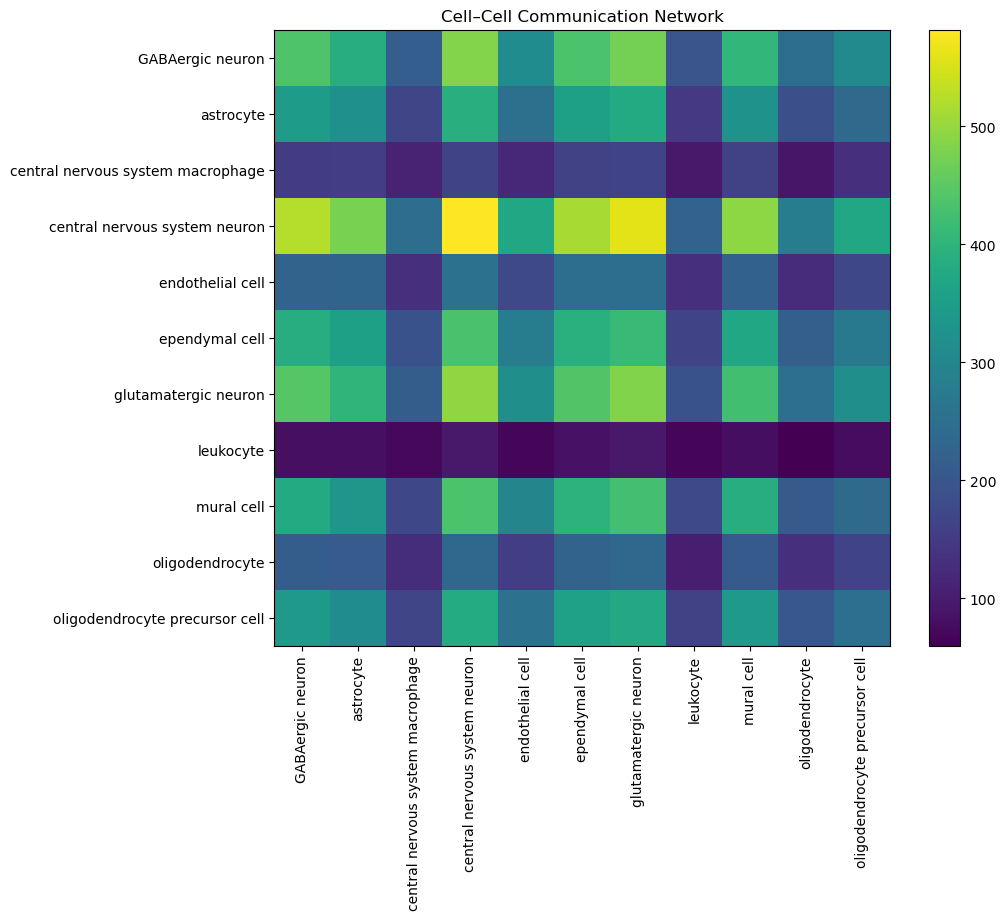

In [31]:
import pandas as pd
import matplotlib.pyplot as plt

heatmap = cell_pairs.pivot(
    index="source",
    columns="target",
    values="n_interactions"
).fillna(0)

plt.figure(figsize=(10,8))
plt.imshow(heatmap)
plt.xticks(range(len(heatmap.columns)), heatmap.columns, rotation=90)
plt.yticks(range(len(heatmap.index)), heatmap.index)
plt.title("Cell–Cell Communication Network")
plt.colorbar()
plt.show()

In [38]:
sig = res[res["cellphone_pvals"] < 0.05].copy()

print("Significant interactions:", sig.shape)

Significant interactions: (21780, 12)


In [39]:
# strongest interaction
sig_sorted = sig.sort_values("lr_means", ascending=False)

sig_sorted.head(20)

,ligand,ligand_complex,ligand_means,ligand_props,receptor,receptor_complex,receptor_means,receptor_props,source,target,lr_means,cellphone_pvals
19074,NLGN1,NLGN1,5.998906,0.999272,NRXN3,NRXN3,6.320374,0.999692,oligodendrocyte precursor cell,GABAergic neuron,6.159640,0.0
32901,NLGN1,NLGN1,5.998906,0.999272,NRXN1,NRXN1,5.934241,0.999085,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.966574,0.0
19053,LRRTM4,LRRTM4,5.574590,0.997673,NRXN3,NRXN3,6.320374,0.999692,oligodendrocyte precursor cell,GABAergic neuron,5.947482,0.0
24307,NLGN1,NLGN1,5.998906,0.999272,NRXN1,NRXN1,5.741495,0.999371,oligodendrocyte precursor cell,glutamatergic neuron,5.870200,0.0
16794,NRG3,NRG3,6.055501,0.998857,ERBB4,ERBB4,5.628139,0.924143,astrocyte,GABAergic neuron,5.841820,0.0
20162,NLGN1,NLGN1,5.268307,0.990463,NRXN3,NRXN3,6.320374,0.999692,central nervous system neuron,GABAergic neuron,5.794341,0.0
32880,LRRTM4,LRRTM4,5.574590,0.997673,NRXN1,NRXN1,5.934241,0.999085,oligodendrocyte precursor cell,oligodendrocyte precursor cell,5.754416,0.0
31331,NRG3,NRG3,6.055501,0.998857,ERBB4,ERBB4,5.433476,0.997486,astrocyte,oligodendrocyte precursor cell,5.744489,0.0
17618,NRG3,NRG3,5.827182,0.999344,ERBB4,ERBB4,5.628139,0.924143,GABAergic neuron,GABAergic neuron,5.727661,0.0
18220,NRG3,NRG3,5.798002,0.999282,ERBB4,ERBB4,5.628139,0.924143,glutamatergic neuron,GABAergic neuron,5.713071,0.0


In [40]:
# group them 

pathway_summary = sig.groupby(["ligand", "receptor"]).size().reset_index(name="count")
pathway_summary.sort_values("count", ascending=False).head(10)

,ligand,receptor,count
70,BMP6,ACVR2A,98
1198,WNT5B,FZD6,96
1079,TGFB1,TGFBR3,87
149,CNTN1,NRCAM,85
71,BMP6,ACVR2B,85
69,BMP6,ACVR1,85
1129,UBASH3B,PPARA,81
853,MPZL1,MPZL1,81
843,LRRTM4,NRXN1,79
987,SEMA3A,NRP1,79


In [41]:
# focus on specific 

synaptic = sig[
    sig["ligand"].str.contains("NLGN|LRRTM|NRG|CADM|NCAM")
]

In [43]:
# who is sending and who is receiving 
sig.groupby(["source", "target"]).size().sort_values(ascending=False).head(10)

source                         target                       
central nervous system neuron  central nervous system neuron    439
                               glutamatergic neuron             412
                               GABAergic neuron                 387
glutamatergic neuron           central nervous system neuron    376
                               glutamatergic neuron             361
GABAergic neuron               central nervous system neuron    360
central nervous system neuron  astrocyte                        359
GABAergic neuron               glutamatergic neuron             349
mural cell                     central nervous system neuron    339
glutamatergic neuron           GABAergic neuron                 336
dtype: int64